<a href="https://colab.research.google.com/github/fleqi/proyecto-mineria/blob/main/hito1/notebooks/datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!git clone https://github.com/fleqi/proyecto-mineria

Cloning into 'proyecto-mineria'...
remote: Enumerating objects: 315, done.
remote: Counting objects: 100% (315/315), done.
remote: Compressing objects: 100% (79/79), done.
remote: Total 315 (delta 227), reused 296 (delta 225), pack-reused 0 (from 0)
Receiving objects: 100% (315/315), 40.31 MiB | 15.11 MiB/s, done.
Resolving deltas: 100% (227/227), done.
Updating files: 100% (254/254), done.


# EDA Hito 1

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
DATA = Path("/content/proyecto-mineria/hito1/data")

## CONAF


Para empezar el análisis exploratorio, podemos fijarnos en los datos de la CONAF, que si bien son poco específicos, al tener los datos agregados por temporada permiten entender mejor las estadísticas.

In [10]:
CONAF = DATA / "conaf"

In [11]:
f1 = CONAF / "1.- Ocurrencia y Daño Histórico Nacional, 1985 - 2024_octubre.xls"
df1 = pd.read_excel(f1, sheet_name="Historico", header=7)
df1 = df1.iloc[2:, 2:7]
df1 = df1.dropna()
df1.columns = "año", "denominacion", "n_incendios", "superficie_ha", "superficie_prom_ha"
df1["año"] = df1["año"].str.slice(0, 4).astype(int)
df1.head()

,año,denominacion,n_incendios,superficie_ha,superficie_prom_ha
2,1963,64.0,435.0,19600.0,45.057471
3,1964,65.0,269.0,17200.0,63.940520
4,1965,66.0,396.0,19900.0,50.252525
5,1966,67.0,307.0,15820.0,51.530945
6,1967,68.0,507.0,61314.0,120.934911


In [12]:
df1.describe()

,año,denominacion,n_incendios,superficie_ha,superficie_prom_ha
count,61.000000,61.000000,61.000000,61.000000,61.000000
mean,1993.000000,53.016393,4641.262295,65912.350987,19.801051
std,17.752934,35.695701,2257.375740,86948.685625,23.609790
min,1963.000000,0.000000,269.000000,9604.000000,2.031436
25%,1978.000000,15.000000,3380.000000,25545.000000,7.569701
50%,1993.000000,69.000000,5252.000000,43592.000000,11.090759
75%,2008.000000,84.000000,6214.000000,80064.190000,16.789704
max,2023.000000,99.000000,8127.000000,570197.394200,120.934911


<Axes: xlabel='año'>

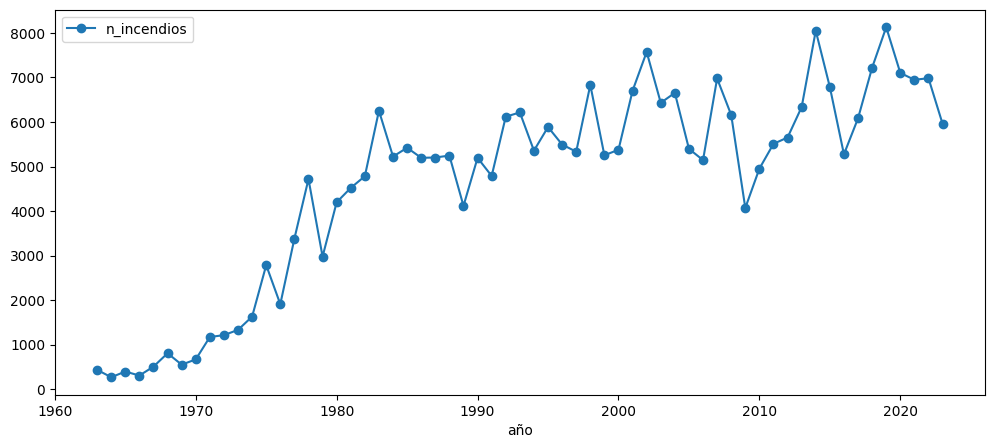

In [13]:
df1.plot.line(x = 'año', y = 'n_incendios', marker = 'o', figsize = (12,5))

Con este gráfico podemos plantearnos si los últimos años de cambio climático tienen influencia sobre la cantidad de incendios anuales.

<Axes: xlabel='año'>

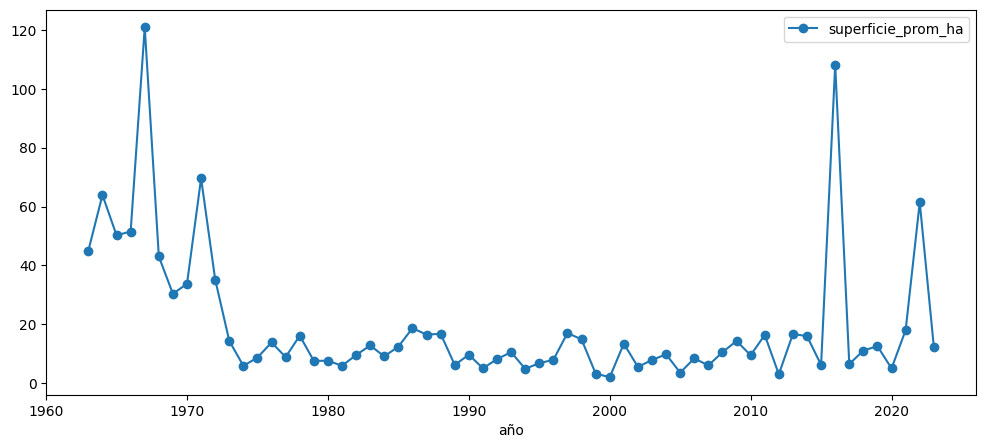

In [14]:
df1.plot.line(x = 'año', y = 'superficie_prom_ha', marker = 'o', figsize = (12,5))

Se nota una clara bajada en la superficie quemada con los años, que se podría atribuir a mejores tecnologías para combatir incendios, sin embargo, en los últimos años se ha evidenciado una subida que se podría atribuir a múltiples causas como la cantidad de incendios contra la capacidad de respuesta o las condiciones climáticas y la influencia que tienen sobre la proliferación de estos.